# Singapore Flat Resale Price Prediction

In [1]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

In [2]:
# Reading the data from all CSV files which is downloded from the source
df1 = pd.read_csv('Data/Resale Flat Prices (Based on Approval Date), 1990 - 1999.csv')
df2 = pd.read_csv('Data/Resale Flat Prices (Based on Approval Date), 2000 - Feb 2012.csv')
df3 = pd.read_csv('Data/Resale Flat Prices (Based on Registration Date), From Mar 2012 to Dec 2014.csv')
df4 = pd.read_csv('Data/Resale Flat Prices (Based on Registration Date), From Jan 2015 to Dec 2016.csv')
df5 = pd.read_csv('Data/Resale flat prices based on registration date from Jan-2017 onwards.csv')

In [3]:
# Checking the shape of the datasets
print("df1",df1.shape)
print("df2",df2.shape)
print("df3",df3.shape)
print("df4",df4.shape)
print("df5",df5.shape)

df1 (287196, 10)
df2 (369651, 10)
df3 (52203, 10)
df4 (37153, 11)
df5 (223889, 11)


In [4]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223889 entries, 0 to 223888
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                223889 non-null  object 
 1   town                 223889 non-null  object 
 2   flat_type            223889 non-null  object 
 3   block                223889 non-null  object 
 4   street_name          223889 non-null  object 
 5   storey_range         223889 non-null  object 
 6   floor_area_sqm       223889 non-null  float64
 7   flat_model           223889 non-null  object 
 8   lease_commence_date  223889 non-null  int64  
 9   remaining_lease      223889 non-null  object 
 10  resale_price         223889 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 18.8+ MB


In [5]:
df4.drop(columns=['remaining_lease'],inplace=True)
df5.drop(columns=['remaining_lease'],inplace=True)

In [6]:
dfs = [df1,df2,df3,df4,df5]
df = pd.concat(dfs,ignore_index=True)

In [7]:
df.shape

(970092, 10)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970092 entries, 0 to 970091
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                970092 non-null  object 
 1   town                 970092 non-null  object 
 2   flat_type            970092 non-null  object 
 3   block                970092 non-null  object 
 4   street_name          970092 non-null  object 
 5   storey_range         970092 non-null  object 
 6   floor_area_sqm       970092 non-null  float64
 7   flat_model           970092 non-null  object 
 8   lease_commence_date  970092 non-null  int64  
 9   resale_price         970092 non-null  float64
dtypes: float64(2), int64(1), object(7)
memory usage: 74.0+ MB


In [9]:
df = df.drop_duplicates()

In [10]:
df['year'] = [int(i[0]) for i in df.month.str.split('-')]
df['mon'] = [int(i[1]) for i in df.month.str.split('-')]

In [11]:
df.drop(columns=['month'],inplace=True)

In [12]:
df.head()

,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,year,mon
0,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977,9000.0,1990,1
1,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,04 TO 06,31.0,IMPROVED,1977,6000.0,1990,1
2,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,10 TO 12,31.0,IMPROVED,1977,8000.0,1990,1
3,ANG MO KIO,1 ROOM,309,ANG MO KIO AVE 1,07 TO 09,31.0,IMPROVED,1977,6000.0,1990,1
4,ANG MO KIO,3 ROOM,216,ANG MO KIO AVE 1,04 TO 06,73.0,NEW GENERATION,1976,47200.0,1990,1


In [13]:
print('Town column unique values:',df.town.nunique())
print('Flat type column unique values:',df.flat_type.nunique())
print('Block column unique values:',df.block.nunique())
print('street_name column unique values:',df.street_name.nunique())
print('storey_range column unique values:',df.storey_range.nunique())
print('flat_model column unique values:',df.flat_model.nunique())

Town column unique values: 27
Flat type column unique values: 8
Block column unique values: 2751
street_name column unique values: 594
storey_range column unique values: 25
flat_model column unique values: 34


In [14]:
df.storey_range.unique()

array(['10 TO 12', '04 TO 06', '07 TO 09', '01 TO 03', '13 TO 15',
       '19 TO 21', '16 TO 18', '25 TO 27', '22 TO 24', '28 TO 30',
       '31 TO 33', '40 TO 42', '37 TO 39', '34 TO 36', '06 TO 10',
       '01 TO 05', '11 TO 15', '16 TO 20', '21 TO 25', '26 TO 30',
       '36 TO 40', '31 TO 35', '46 TO 48', '43 TO 45', '49 TO 51'],
      dtype=object)

In [15]:
def extract_storey_midpoint(storey_range):
    if ' TO ' in storey_range:
        parts = storey_range.split(' TO ')
    else:
        try:
            return float(storey_range)
        except ValueError:
            return None

    lower = int(parts[0])
    upper = int(parts[1])
    return (lower + upper) / 2

df['storey_mid'] = df['storey_range'].apply(extract_storey_midpoint)
df.drop(columns=['storey_range'],inplace=True)

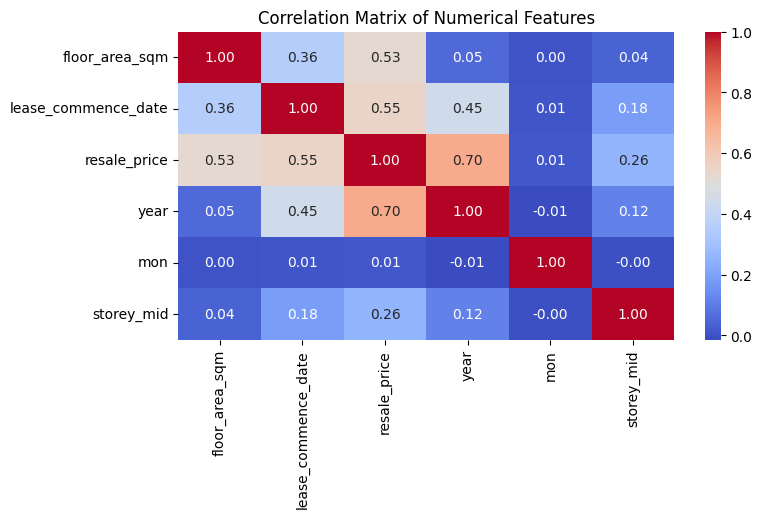

In [16]:
numerical_cols = df.select_dtypes(include=['number']).columns

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [17]:
list(df.columns)

['town',
 'flat_type',
 'block',
 'street_name',
 'floor_area_sqm',
 'flat_model',
 'lease_commence_date',
 'resale_price',
 'year',
 'mon',
 'storey_mid']

In [18]:
block_freq = df.block.value_counts()
df['block_freq'] = df['block'].map(block_freq)
df.drop(columns=['block'], inplace=True)

In [19]:
import joblib
joblib.dump(block_freq, "block_freq.pkl")

['block_freq.pkl']

In [20]:
street_freq = df['street_name'].value_counts()
df['street_freq'] = df['street_name'].map(street_freq)
df.drop(columns=['street_name'], inplace=True)

In [21]:
import joblib
joblib.dump(street_freq,"street_freq.pkl")

['street_freq.pkl']

In [22]:
ss = list(df.flat_model.unique())
ss.sort()
ss

['2-ROOM',
 '2-room',
 '3Gen',
 'APARTMENT',
 'Adjoined flat',
 'Apartment',
 'DBSS',
 'IMPROVED',
 'IMPROVED-MAISONETTE',
 'Improved',
 'Improved-Maisonette',
 'MAISONETTE',
 'MODEL A',
 'MODEL A-MAISONETTE',
 'MULTI GENERATION',
 'Maisonette',
 'Model A',
 'Model A-Maisonette',
 'Model A2',
 'Multi Generation',
 'NEW GENERATION',
 'New Generation',
 'PREMIUM APARTMENT',
 'Premium Apartment',
 'Premium Apartment Loft',
 'Premium Maisonette',
 'SIMPLIFIED',
 'STANDARD',
 'Simplified',
 'Standard',
 'TERRACE',
 'Terrace',
 'Type S1',
 'Type S2']

In [23]:
df.flat_model = df.flat_model.replace('STANDARD','Standard')
df.flat_model = df.flat_model.replace('TERRACE','Terrace')
df.flat_model = df.flat_model.replace('SIMPLIFIED','Simplified')
df.flat_model = df.flat_model.replace('PREMIUM APARTMENT','Premium Apartment')
df.flat_model = df.flat_model.replace('NEW GENERATION','New Generation')
df.flat_model = df.flat_model.replace('MULTI GENERATION','Multi Generation')
df.flat_model = df.flat_model.replace('MULTI GENERATION','Multi Generation')
df.flat_model = df.flat_model.replace('MODEL A','Model A')
df.flat_model = df.flat_model.replace('MAISONETTE','Maisonette')
df.flat_model = df.flat_model.replace('MODEL A-MAISONETTE','Model A-Maisonette')
df.flat_model = df.flat_model.replace('2-ROOM','2-room')
df.flat_model = df.flat_model.replace('APARTMENT','Apartment')
df.flat_model = df.flat_model.replace('IMPROVED','Improved')
df.flat_model = df.flat_model.replace('IMPROVED-MAISONETTE','Improved-Maisonette')

In [24]:
df.flat_type = df.flat_type.replace('MULTI GENERATION','MULTI-GENERATION')

In [25]:
ohe = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
encoded = ohe.fit_transform(df[['town','flat_type','flat_model']])
encoded_df = pd.DataFrame(encoded,columns = ohe.get_feature_names_out(['town','flat_type','flat_model']))

In [26]:
df = pd.concat([df.drop(columns=['town','flat_type','flat_model']).reset_index(drop=True),
                encoded_df.reset_index(drop=True)], axis=1)

In [1]:
import joblib
joblib.dump(ohe, 'ohe.pkl')

NameError: name 'ohe' is not defined

In [28]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

Shape: (968087, 63)

Data types:
floor_area_sqm           float64
lease_commence_date        int64
resale_price             float64
year                       int64
mon                        int64
                          ...   
flat_model_Simplified    float64
flat_model_Standard      float64
flat_model_Terrace       float64
flat_model_Type S1       float64
flat_model_Type S2       float64
Length: 63, dtype: object


In [29]:
# Prepare features (X) and target (y)
# Target is resale_price
X = df.drop(columns=['resale_price'])
y = df['resale_price']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Features shape: (968087, 62)
Target shape: (968087,)

Feature columns: ['floor_area_sqm', 'lease_commence_date', 'year', 'mon', 'storey_mid', 'block_freq', 'street_freq', 'town_ANG MO KIO', 'town_BEDOK', 'town_BISHAN', 'town_BUKIT BATOK', 'town_BUKIT MERAH', 'town_BUKIT PANJANG', 'town_BUKIT TIMAH', 'town_CENTRAL AREA', 'town_CHOA CHU KANG', 'town_CLEMENTI', 'town_GEYLANG', 'town_HOUGANG', 'town_JURONG EAST', 'town_JURONG WEST', 'town_KALLANG/WHAMPOA', 'town_LIM CHU KANG', 'town_MARINE PARADE', 'town_PASIR RIS', 'town_PUNGGOL', 'town_QUEENSTOWN', 'town_SEMBAWANG', 'town_SENGKANG', 'town_SERANGOON', 'town_TAMPINES', 'town_TOA PAYOH', 'town_WOODLANDS', 'town_YISHUN', 'flat_type_1 ROOM', 'flat_type_2 ROOM', 'flat_type_3 ROOM', 'flat_type_4 ROOM', 'flat_type_5 ROOM', 'flat_type_EXECUTIVE', 'flat_type_MULTI-GENERATION', 'flat_model_2-room', 'flat_model_3Gen', 'flat_model_Adjoined flat', 'flat_model_Apartment', 'flat_model_DBSS', 'flat_model_Improved', 'flat_model_Improved-Maisonette', 'flat

In [30]:
# Applying log transformation to the target variable
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("Log transformation applied to target variable (y_train and y_test).")
print(f"Original y_train mean: {y_train.mean():,.2f}")
print(f"Log-transformed y_train mean: {y_train_log.mean():,.2f}")
print(f"Original y_test mean: {y_test.mean():,.2f}")
print(f"Log-transformed y_test mean: {y_test_log.mean():,.2f}")

y_train = y_train_log
y_test = y_test_log

Log transformation applied to target variable (y_train and y_test).
Original y_train mean: 335,121.90
Log-transformed y_train mean: 12.56
Original y_test mean: 335,208.75
Log-transformed y_test mean: 12.56


In [31]:
rf_model = RandomForestRegressor(
    n_estimators=15,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\nTraining Random Forest model...")
rf_model.fit(X_train, y_train)

# Make predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Evaluate model
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Calculate Adjusted R-squared
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

n_train = X_train.shape[0]
p_train = X_train.shape[1]
n_test = X_test.shape[0]
p_test = X_test.shape[1]

train_adj_r2 = adjusted_r2(train_r2, n_train, p_train)
test_adj_r2 = adjusted_r2(test_r2, n_test, p_test)

print("\n" + "="*50)
print("MODEL PERFORMANCE")
print("="*50)
print(f"\nTraining Set:")
print(f"  RMSE: ${np.expm1(train_rmse):,.2f}")
print(f"  MAE:  ${np.expm1(train_mae):,.2f}")
print(f"  R²:   {train_r2:.4f}")
print(f"  Adjusted R²: {train_adj_r2:.4f}")

print(f"\nTesting Set:")
print(f"  RMSE: ${np.expm1(test_rmse):,.2f}")
print(f"  MAE:  ${np.expm1(test_mae):,.2f}")
print(f"  R²:   {test_r2:.4f}")
print(f"  Adjusted R²: {test_adj_r2:.4f}")


Training Random Forest model...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 out of  15 | elapsed:  1.3min remaining:  1.2min
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:  1.7min finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   8 out of  15 | elapsed:    2.4s remaining:    2.1s
[Parallel(n_jobs=12)]: Done  15 out of  15 | elapsed:    3.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   8 out of  15 | elapsed:    0.5s remaining:    0.4s
[Parallel(n_jobs=12)]: Done  15 out of  15 | elapsed:    0.6s finished



MODEL PERFORMANCE

Training Set:
  RMSE: $0.08
  MAE:  $0.06
  R²:   0.9831
  Adjusted R²: 0.9831

Testing Set:
  RMSE: $0.09
  MAE:  $0.07
  R²:   0.9789
  Adjusted R²: 0.9789


In [32]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*50)
print("TOP 10 IMPORTANT FEATURES")
print("="*50)
print(feature_importance.head(10).to_string(index=False))


TOP 10 IMPORTANT FEATURES
            feature  importance
               year    0.610949
     floor_area_sqm    0.316576
lease_commence_date    0.010102
   flat_type_4 ROOM    0.009347
         storey_mid    0.005329
                mon    0.004998
        street_freq    0.004098
   town_BUKIT MERAH    0.003698
     town_WOODLANDS    0.003585
   town_JURONG WEST    0.003377


In [33]:
import pickle
with open('model.pkl','wb') as f:
  pickle.dump(rf_model,f)